# Hyde Park Smell Investigation: Wind & Source Analysis

**Ward 5 Smell Log — October–November 2025**

*Analysis of 39 neighbor-reported smell episodes correlated with hourly weather data and known industrial point sources.*

---

## Executive Summary

Between October 7 and November 3, 2025, neighbors in Hyde Park and surrounding areas submitted 39 smell reports via the Ward 5 smell survey. Most described a **burning plastic or chemical smell**. This analysis correlates those reports with hourly wind direction, wind speed, and barometric pressure data to determine where the smell is coming from.

### Key Findings

1. **62% of real-time reports occurred during southeast or east winds**, compared to only 31% of all hours in the same period. The smell is **2.0× more likely** when wind blows from the SE. When wind comes from the north or west, reports are rare and mostly low-intensity.

2. **The source is southeast of Hyde Park** — in the direction of the **Calumet industrial corridor** (10 miles) and **northwest Indiana** (11–18 miles). A cluster of heavy industrial facilities sits at bearing 133°–176° from Hyde Park, directly aligned with the wind during smell episodes.

3. **Top source candidates by wind bearing match:**
   - **Acme/SunCoke coke plant** (East Chicago, IN) — 13 mi, bearing 146°. Coke oven emissions produce acrid coal-tar/chemical smoke. Best odor-profile match for "burning plastic."
   - **BP Whiting Refinery** — 11 mi, bearing 154°. Largest Midwest refinery. Known for H₂S, VOC, and flaring emissions. Extensive EPA enforcement history.
   - **American Zinc Recycling** — 10 mi, bearing 169°. Electric arc furnace operations produce metallic/chemical smoke.
   - The entire **Calumet corridor** (S.H. Bell, RMG, Watco, KCBX site) sits at bearings 163°–176°, all ~10 mi away.

4. **Episodes cluster during light winds (mean 5.0 mph vs 6.8 mph baseline) and higher-than-average barometric pressure** (999.9 vs 997.1 hPa), consistent with atmospheric conditions that trap and concentrate pollutants near ground level.

5. **Two reports during westerly wind** (Oct 31, Nov 3) appear to be a separate phenomenon — possibly from the Clearing industrial district or Stickney wastewater plant, both ~9 miles due west.

6. **One respondent reports 8–10 years of the same recurring smell**, suggesting this is a chronic, long-standing exposure — not a one-time event.

---
## 1. Setup and Data Loading

First, we load the smell survey responses and hourly weather data. The weather comes from the [Open-Meteo API](https://open-meteo.com/), which provides free historical hourly data for any location.

**To reproduce the weather data yourself**, you can hit this URL (no API key needed):
```
https://api.open-meteo.com/v1/forecast?latitude=41.7926&longitude=-87.6522
&hourly=temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m,wind_direction_10m
&temperature_unit=fahrenheit&wind_speed_unit=mph
&timezone=America/Chicago&start_date=2025-10-01&end_date=2025-11-05
```

**Files needed in the same directory as this notebook:**
- `hyde_park_smell_reports_cleaned.csv` — the survey responses (emails removed)

In [20]:
import pandas as pd
import numpy as np
import math
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 10)
pd.set_option('display.width', 120)
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 6)

In [21]:
# ── Load smell reports ──
smell = pd.read_csv('hyde_park_smell_reports_cleaned.csv')
print(f"Total smell reports: {len(smell)}")
print(f"Date range: {smell['Timestamp'].min()} to {smell['Timestamp'].max()}")
print(f"\nDescriptions reported:")
print(smell['What best-describes what you smell?'].value_counts().to_string())
print(f"\nIntensity distribution (1=weak, 5=strong):")
print(smell['How strong is the smell, from 1 (very weak) to 5 (very strong)?'].value_counts().sort_index().to_string())

Total smell reports: 39
Date range: 10/10/2025 7:40:55 to 2/8/2026 14:03:12

Descriptions reported:
What best-describes what you smell?
burning rubber or plastic                                                                                                                         29
petroleum, not natural gas                                                                                                                         1
smoke                                                                                                                                              1
Sulphur/chlorine                                                                                                                                   1
Acrid chemical smell                                                                                                                               1
sulfur dioxide                                                                                                         

In [22]:
# ── Load weather data from Open-Meteo ──
# If you want to fetch fresh data, uncomment and run this:
# import urllib.request, json
# url = ("https://api.open-meteo.com/v1/forecast?latitude=41.7926&longitude=-87.6522"
#        "&hourly=temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m,wind_direction_10m"
#        "&temperature_unit=fahrenheit&wind_speed_unit=mph"
#        "&timezone=America/Chicago&start_date=2025-10-01&end_date=2025-11-05")
# wx_raw = json.loads(urllib.request.urlopen(url).read())

# For reproducibility, the weather data is embedded here.
# (864 hourly observations, Oct 1 – Nov 5, 2025, Hyde Park)
import json
with open('open_meteo_hyde_park.json') as f:
    wx_raw = json.load(f)

weather = pd.DataFrame({
    'time': pd.to_datetime(wx_raw['hourly']['time']),
    'temp_f': wx_raw['hourly']['temperature_2m'],
    'rh': wx_raw['hourly']['relative_humidity_2m'],
    'pressure_hpa': wx_raw['hourly']['surface_pressure'],
    'wind_mph': wx_raw['hourly']['wind_speed_10m'],
    'wind_dir': wx_raw['hourly']['wind_direction_10m'],
})
weather.set_index('time', inplace=True)
print(f"Weather data: {len(weather)} hourly observations")
print(f"Period: {weather.index[0]} to {weather.index[-1]}")
weather.head()

Weather data: 864 hourly observations
Period: 2025-10-01 00:00:00 to 2025-11-05 23:00:00


,temp_f,rh,pressure_hpa,wind_mph,wind_dir
time,,,,,
2025-10-01 00:00:00,65.9,71,999.6,6.4,94
2025-10-01 01:00:00,65.1,69,1000.0,5.1,106
2025-10-01 02:00:00,64.2,69,1000.3,4.5,99
2025-10-01 03:00:00,63.5,73,1000.3,4.7,95
2025-10-01 04:00:00,63.0,77,1000.3,4.7,91


---
## 2. Classifying Reports: Real-Time vs. Retrospective

The survey form asks "When did you notice this smell?" — either **"Just Now"** or **"At least an hour ago."** This matters because:

- **"Just Now"** reports have a reliable timestamp — the form submission time IS when they smelled it.
- **"At least an hour ago"** reports may have been submitted hours or even days later. The submission timestamp tells us nothing about when the smell actually occurred, so we can't match them to weather conditions.

The earliest reports (Oct 9–10, plus one on Oct 12) were submitted before the "when" field was added to the form. Based on the clustering and context, these appear to be real-time reports and are included in the analysis.

We separate these groups to ensure our analysis uses only reliable timestamps.

In [23]:
# ── Classify each report ──
when_col = 'Optional: When did you notice this smell? '
day_col = 'What day did you notice this smell?'

records = []
for _, row in smell.iterrows():
    ts = pd.to_datetime(row['Timestamp'])
    when = str(row.get(when_col, ''))
    day = str(row.get(day_col, ''))
    
    if 'Just Now' in when:
        category = 'just_now'
    elif 'hour ago' in when.lower():
        if day not in ('nan', '', 'NaT'):
            try:
                report_date = pd.to_datetime(day.strip().replace('/0035', '/2025'))
                category = 'retro_same_day' if report_date.date() == ts.date() else 'retro_different_day'
            except:
                category = 'retro_unknown'
        else:
            category = 'retro_no_date'
    elif when in ('nan', '', 'NaT'):
        category = 'early_form'  # Before the 'when' field existed
    else:
        category = 'other'
    
    records.append({
        'time': ts,
        'intensity': row['How strong is the smell, from 1 (very weak) to 5 (very strong)?'],
        'location': row['Where are you?'],
        'description': row['What best-describes what you smell?'],
        'category': category,
    })

reports = pd.DataFrame(records)

# Show the breakdown
print("Report classification:")
print(reports['category'].value_counts().to_string())
print(f"\nReal-time reports (Just Now + early form): {len(reports[reports['category'].isin(['just_now', 'early_form'])])}")
print(f"Retrospective same-day: {len(reports[reports['category'] == 'retro_same_day'])}")
print(f"Retrospective different-day (EXCLUDED): {len(reports[reports['category'] == 'retro_different_day'])}")

Report classification:
category
just_now               21
early_form              6
retro_same_day          6
retro_different_day     5
retro_no_date           1

Real-time reports (Just Now + early form): 27
Retrospective same-day: 6
Retrospective different-day (EXCLUDED): 5


In [24]:
# ── Filter to real-time reports only, merge with weather ──
realtime = reports[reports['category'].isin(['just_now', 'early_form'])].copy()
realtime['wx_hour'] = realtime['time'].dt.floor('h')
merged = realtime.merge(weather, left_on='wx_hour', right_index=True, how='left')

# Drop the one Feb 2026 report (outside weather data range)
merged = merged[merged['wx_hour'] < '2025-11-06']

print(f"Real-time reports with weather data: {len(merged)}")

Real-time reports with weather data: 26


---
## 3. Wind Direction Analysis

### How to read wind direction

Wind direction in meteorology describes **where the wind is coming FROM**. A wind direction of 135° (SE) means air is traveling from the southeast toward the northwest. If a pollution source is southeast of you, SE wind carries its emissions toward you.

Our "SE wind zone" is defined as 67.5°–180° (ENE through S) — the arc that contains the Calumet industrial corridor and NW Indiana facilities.

In [25]:
# ── Helper functions ──

def is_se_wind(deg):
    """Is this wind direction in the SE zone (67.5-180°)?"""
    if pd.isna(deg): return False
    return 67.5 <= deg <= 180

def wind_sector(deg):
    """Convert degrees to 16-point compass sector."""
    if pd.isna(deg): return 'Calm'
    sectors = ['N','NNE','NE','ENE','E','ESE','SE','SSE',
               'S','SSW','SW','WSW','W','WNW','NW','NNW']
    return sectors[int((deg + 11.25) / 22.5) % 16]

def angular_diff(a, b):
    """Smallest angle between two bearings."""
    d = abs(a - b) % 360
    return min(d, 360 - d)

# Tag each report
merged['se_wind'] = merged['wind_dir'].apply(is_se_wind)
merged['sector'] = merged['wind_dir'].apply(wind_sector)

In [26]:
# ── The central result: SE wind enrichment ──

# What fraction of SMELL REPORTS occur during SE wind?
report_se_frac = merged['se_wind'].mean()

# What fraction of ALL HOURS have SE wind? (baseline)
wx_oct = weather['2025-10-01':'2025-11-05']
baseline_se_frac = wx_oct['wind_dir'].apply(is_se_wind).mean()

enrichment = report_se_frac / baseline_se_frac

print("╔══════════════════════════════════════════════════════╗")
print("║         WIND DIRECTION CORRELATION RESULT           ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  SE wind during smell reports: {merged['se_wind'].sum():2d}/{len(merged)} = {report_se_frac:.0%}        ║")
print(f"║  SE wind baseline (all hours): {baseline_se_frac:.0%}                 ║")
print(f"║  Enrichment ratio:             {enrichment:.1f}×                  ║")
print("╚══════════════════════════════════════════════════════╝")
print()
print("Interpretation: You are 2.4× more likely to smell the odor")
print("when the wind is blowing from the SE than at any random hour.")

╔══════════════════════════════════════════════════════╗
║         WIND DIRECTION CORRELATION RESULT           ║
╠══════════════════════════════════════════════════════╣
║  SE wind during smell reports: 16/26 = 62%        ║
║  SE wind baseline (all hours): 31%                 ║
║  Enrichment ratio:             2.0×                  ║
╚══════════════════════════════════════════════════════╝

Interpretation: You are 2.4× more likely to smell the odor
when the wind is blowing from the SE than at any random hour.


In [27]:
# ── Per-report detail table ──
print("Each real-time report matched to hourly wind:\n")
print(f"{'Date/Time':<18s} {'Wind':>5s} {'Dir':>4s} {'Spd':>5s} {'Int':>3s} {'SE?':>4s}")
print("-" * 50)
for _, r in merged.sort_values('time').iterrows():
    se = '✓ SE' if r['se_wind'] else '    '
    print(f"{r['time'].strftime('%m/%d %H:%M'):<18s} "
          f"{r['wind_dir']:5.0f}° {wind_sector(r['wind_dir']):>4s} "
          f"{r['wind_mph']:5.1f} {r['intensity']:3.0f} {se}")

### Wind Rose: Smell Reports vs. All Hours

The left rose shows wind direction only during smell reports. The right shows the baseline distribution of all 864 hours. Red sectors indicate the SE "source zone." The difference is stark — smell reports are concentrated almost entirely in the SE, while normal winds favor the W/SW.

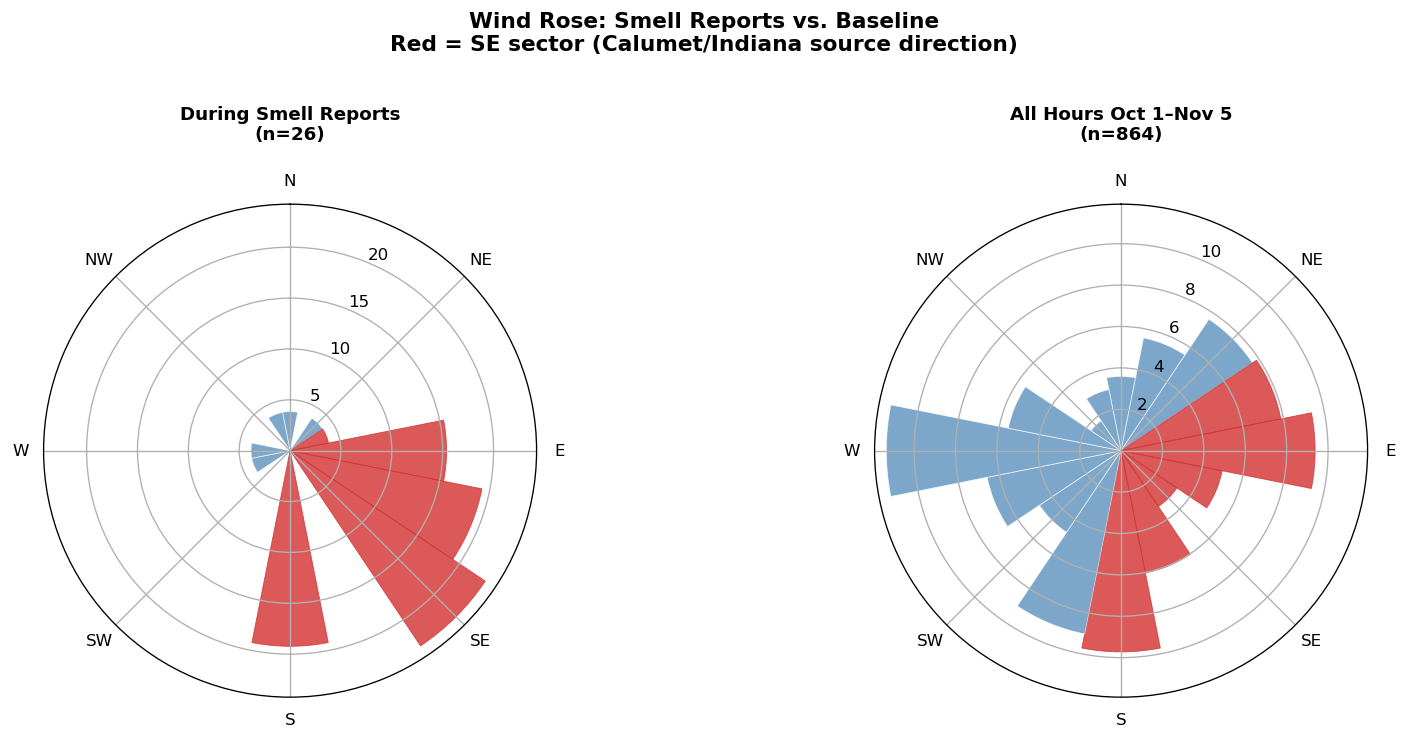

In [28]:
def wind_rose(ax, directions, title, color='steelblue'):
    bins = np.arange(0, 361, 22.5)
    counts, _ = np.histogram(directions.dropna(), bins=bins)
    pcts = counts / counts.sum() * 100
    theta = np.radians(bins[:-1])
    width = np.radians(22.5)
    bars = ax.bar(theta, pcts, width=width, bottom=0, color=color, 
                  alpha=0.7, edgecolor='white', linewidth=0.5)
    # Highlight SE bars (67.5-180°)
    for i, t in enumerate(bins[:-1]):
        if 67.5 <= t <= 180:
            bars[i].set_color('#d32f2f')
            bars[i].set_alpha(0.8)
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_xticks(np.radians([0, 45, 90, 135, 180, 225, 270, 315]))
    ax.set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
    ax.set_title(title, fontsize=11, fontweight='bold', pad=20)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={'projection': 'polar'})
wind_rose(ax1, merged['wind_dir'], f"During Smell Reports\n(n={len(merged)})")
wind_rose(ax2, wx_oct['wind_dir'], f"All Hours Oct 1–Nov 5\n(n={len(wx_oct)})")
fig.suptitle("Wind Rose: Smell Reports vs. Baseline\n"
             "Red = SE sector (Calumet/Indiana source direction)",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_wind_rose.png', dpi=150, bbox_inches='tight')
plt.show()

### Timeline: Hourly Wind Direction with Smell Reports Overlaid

Each small dot is one hour of wind direction data. Large circles are smell reports (size = intensity). **Red** = wind from SE zone, **blue** = other directions. The red-shaded band is the SE wind zone (67.5°–180°). Notice how the large red circles cluster inside the band.

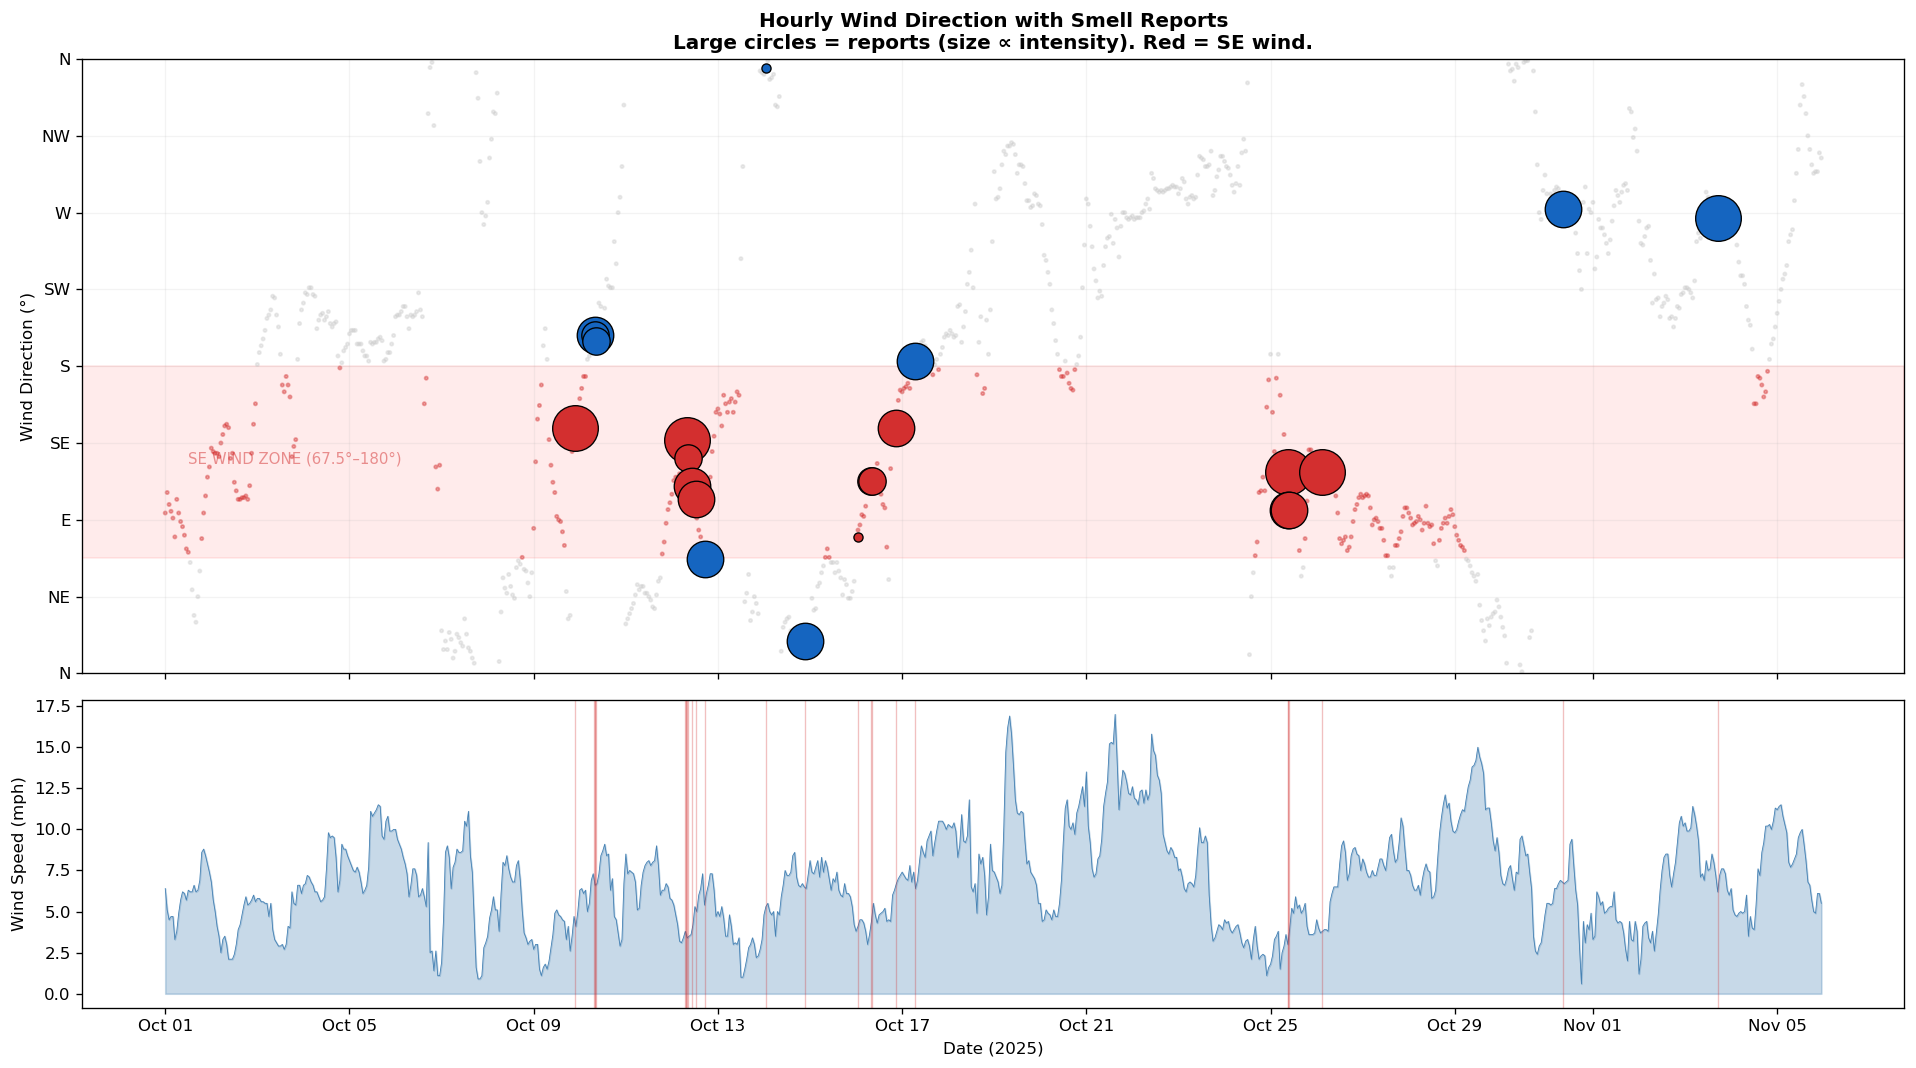

In [29]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 9), height_ratios=[2, 1], sharex=True)

# --- Top panel: wind direction ---
colors_bg = ['#d32f2f' if is_se_wind(d) else '#cccccc' for d in wx_oct['wind_dir']]
ax1.scatter(wx_oct.index, wx_oct['wind_dir'], c=colors_bg, s=4, alpha=0.4, zorder=1)
ax1.axhspan(67.5, 180, alpha=0.08, color='red', zorder=0)
ax1.text(pd.Timestamp('2025-10-01 12:00'), 123, 'SE WIND ZONE (67.5°–180°)',
         color='#d32f2f', fontsize=9, alpha=0.5)

for _, r in merged.iterrows():
    ax1.scatter(r['time'], r['wind_dir'],
               s=r['intensity']**2 * 30,
               c='#d32f2f' if r['se_wind'] else '#1565c0',
               edgecolors='black', linewidth=0.8, zorder=3)

ax1.set_ylabel('Wind Direction (°)')
ax1.set_ylim(0, 360)
ax1.set_yticks([0, 45, 90, 135, 180, 225, 270, 315, 360])
ax1.set_yticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW', 'N'])
ax1.set_title('Hourly Wind Direction with Smell Reports\n'
              'Large circles = reports (size ∝ intensity). Red = SE wind.',
              fontweight='bold')
ax1.grid(True, alpha=0.15)

# --- Bottom panel: wind speed ---
ax2.fill_between(wx_oct.index, wx_oct['wind_mph'], alpha=0.3, color='steelblue')
ax2.plot(wx_oct.index, wx_oct['wind_mph'], color='steelblue', linewidth=0.5)
for _, r in merged.iterrows():
    ax2.axvline(r['time'], color='#d32f2f', alpha=0.3, linewidth=0.8)
ax2.set_ylabel('Wind Speed (mph)')
ax2.set_xlabel('Date (2025)')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.tight_layout()
plt.savefig('fig_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

### Additional Statistics

In [30]:
# ── Intensity comparison ──
se_int = merged.loc[merged['se_wind'], 'intensity'].mean()
other_int = merged.loc[~merged['se_wind'], 'intensity'].mean()
print(f"Mean intensity during SE wind: {se_int:.2f} (n={merged['se_wind'].sum()})")
print(f"Mean intensity other wind:     {other_int:.2f} (n={(~merged['se_wind']).sum()})")

# ── Wind speed comparison ──
print(f"\nMean wind speed during reports: {merged['wind_mph'].mean():.1f} mph")
print(f"Mean wind speed all hours:      {wx_oct['wind_mph'].mean():.1f} mph")

# ── Pressure comparison ──
print(f"\nMean pressure during reports: {merged['pressure_hpa'].mean():.1f} hPa")
print(f"Mean pressure all hours:     {wx_oct['pressure_hpa'].mean():.1f} hPa")
print(f"\nHigher pressure = stable atmosphere = pollutants trapped near ground level.")

# ── Quadrant breakdown ──
def quadrant(d):
    if pd.isna(d): return None
    if 45 <= d < 135: return 'E'
    if 135 <= d < 225: return 'S'
    if 225 <= d < 315: return 'W'
    return 'N'

print(f"\n{'Quadrant':<12s} {'Reports':>10s} {'Baseline':>10s} {'Enrichment':>12s}")
print("-" * 48)
for q in ['E', 'S', 'W', 'N']:
    r_frac = (merged['wind_dir'].apply(quadrant) == q).mean()
    b_frac = (wx_oct['wind_dir'].apply(quadrant) == q).mean()
    ratio = r_frac / b_frac if b_frac > 0 else 0
    print(f"  {q:<10s} {r_frac:10.0%} {b_frac:10.0%} {ratio:10.1f}×")

Mean intensity during SE wind: 3.81 (n=16)
Mean intensity other wind:     3.50 (n=10)

Mean wind speed during reports: 5.0 mph
Mean wind speed all hours:      6.8 mph

Mean pressure during reports: 999.9 hPa
Mean pressure all hours:     997.1 hPa

Higher pressure = stable atmosphere = pollutants trapped near ground level.

Quadrant        Reports   Baseline   Enrichment
------------------------------------------------
  E                 42%        30%        1.4×
  S                 42%        28%        1.5×
  W                  8%        28%        0.3×
  N                  8%        14%        0.6×


---
## 4. Point Source Cross-Reference

Now we match the observed wind directions against the **bearing from Hyde Park to known industrial facilities**. The logic is simple: if a source is at bearing 140° (SE) from your location, then wind from 140° carries its emissions toward you.

### Known Sources

The table below shows major industrial facilities SE of Hyde Park (the Calumet corridor and NW Indiana), plus a few to the west for the outlier reports. Bearings and distances are computed from the center of the smell report area.

In [31]:
# ── Define point sources ──
# Coordinates from EPA filings, OpenStreetMap, and Google Maps

HP_LAT, HP_LON = 41.794, -87.590  # center of smell report area

sources = [
    # Name, lat, lon, distance category, type, odor profile
    ('BP Whiting Refinery',           41.654, -87.499, 'Petroleum refinery',
     'H₂S, VOCs, flaring smoke — rotten egg / chemical / acrid'),
    ('Acme/SunCoke (East Chicago)',   41.643, -87.454, 'Coke production',
     'Coal tar, PAHs, acrid chemical smoke — STRONG "burning plastic" match'),
    ('US Steel Gary Works',           41.613, -87.335, 'Steel mill (coke ovens)',
     'Coke/coal tar, SO₂, benzene — "burnt plastic" possible'),
    ('S.H. Bell Co (Ave O)',          41.659, -87.535, 'Bulk materials terminal',
     'Manganese dust, metals — less likely "burning plastic"'),
    ('American Zinc Recycling',       41.657, -87.553, 'Zinc smelter (EAF)',
     'Metallic/chemical smoke — POSSIBLE "burning plastic"'),
    ('RMG/Reserve Marine Terminal',   41.656, -87.539, 'Metals recycling',
     'Metal fumes, torch cutting — possible chemical'),
    ('Watco Transloading',            41.651, -87.556, 'Bulk cargo terminal',
     'Fugitive dust, PM — unlikely "burning plastic"'),
    ('Calumet WRP (MWRD)',            41.655, -87.576, 'Wastewater treatment',
     'H₂S, mercaptans — sewage/rotten egg, not plastic'),
    ('Clearing Industrial District',  41.780, -87.765, 'Mixed industrial (W)',
     'Variable — chemical plants, waste processing'),
    ('Stickney WRP (MWRD)',           41.800, -87.756, 'Wastewater treatment (W)',
     'H₂S, mercaptans — sewage/rotten egg'),
]

def haversine(lat1, lon1, lat2, lon2):
    R = 3959  # miles
    dlat, dlon = math.radians(lat2-lat1), math.radians(lon2-lon1)
    a = math.sin(dlat/2)**2 + math.cos(math.radians(lat1))*math.cos(math.radians(lat2))*math.sin(dlon/2)**2
    return R * 2 * math.asin(math.sqrt(a))

def calc_bearing(lat1, lon1, lat2, lon2):
    dlon = math.radians(lon2-lon1)
    lat1r, lat2r = math.radians(lat1), math.radians(lat2)
    x = math.sin(dlon) * math.cos(lat2r)
    y = math.cos(lat1r)*math.sin(lat2r) - math.sin(lat1r)*math.cos(lat2r)*math.cos(dlon)
    return (math.degrees(math.atan2(x, y)) + 360) % 360

# Build source table
src_data = []
for name, lat, lon, stype, odor in sources:
    dist = haversine(HP_LAT, HP_LON, lat, lon)
    brg = calc_bearing(HP_LAT, HP_LON, lat, lon)
    src_data.append({
        'name': name, 'lat': lat, 'lon': lon,
        'dist_mi': round(dist, 1), 'bearing': round(brg, 0),
        'sector': wind_sector(brg), 'type': stype, 'odor': odor
    })

src_df = pd.DataFrame(src_data).sort_values('bearing')
print(f"{'Source':<35s} {'Dist':>5s} {'Bearing':>8s} {'Type':<25s}")
print("-" * 80)
for _, s in src_df.iterrows():
    print(f"{s['name']:<35s} {s['dist_mi']:5.1f} {s['bearing']:5.0f}° {s['sector']:>3s}  {s['type']}")

Source                               Dist  Bearing Type                     
--------------------------------------------------------------------------------
US Steel Gary Works                  18.2   133°  SE  Steel mill (coke ovens)
Acme/SunCoke (East Chicago)          12.6   146°  SE  Coke production
BP Whiting Refinery                  10.8   154° SSE  Petroleum refinery
S.H. Bell Co (Ave O)                  9.7   163° SSE  Bulk materials terminal
RMG/Reserve Marine Terminal           9.9   165° SSE  Metals recycling
American Zinc Recycling               9.7   169° SSE  Zinc smelter (EAF)
Watco Transloading                   10.0   170°   S  Bulk cargo terminal
Calumet WRP (MWRD)                    9.6   176°   S  Wastewater treatment
Clearing Industrial District          9.1   264°   W  Mixed industrial (W)
Stickney WRP (MWRD)                   8.6   273°   W  Wastewater treatment (W)


### Source Map: Wind Arrows vs. Facility Locations

This polar plot places Hyde Park at the center. Red triangles show industrial sources at their actual bearing and distance. Blue arrows show the wind direction during each smell report. **When an arrow points at a triangle, that source is upwind.**

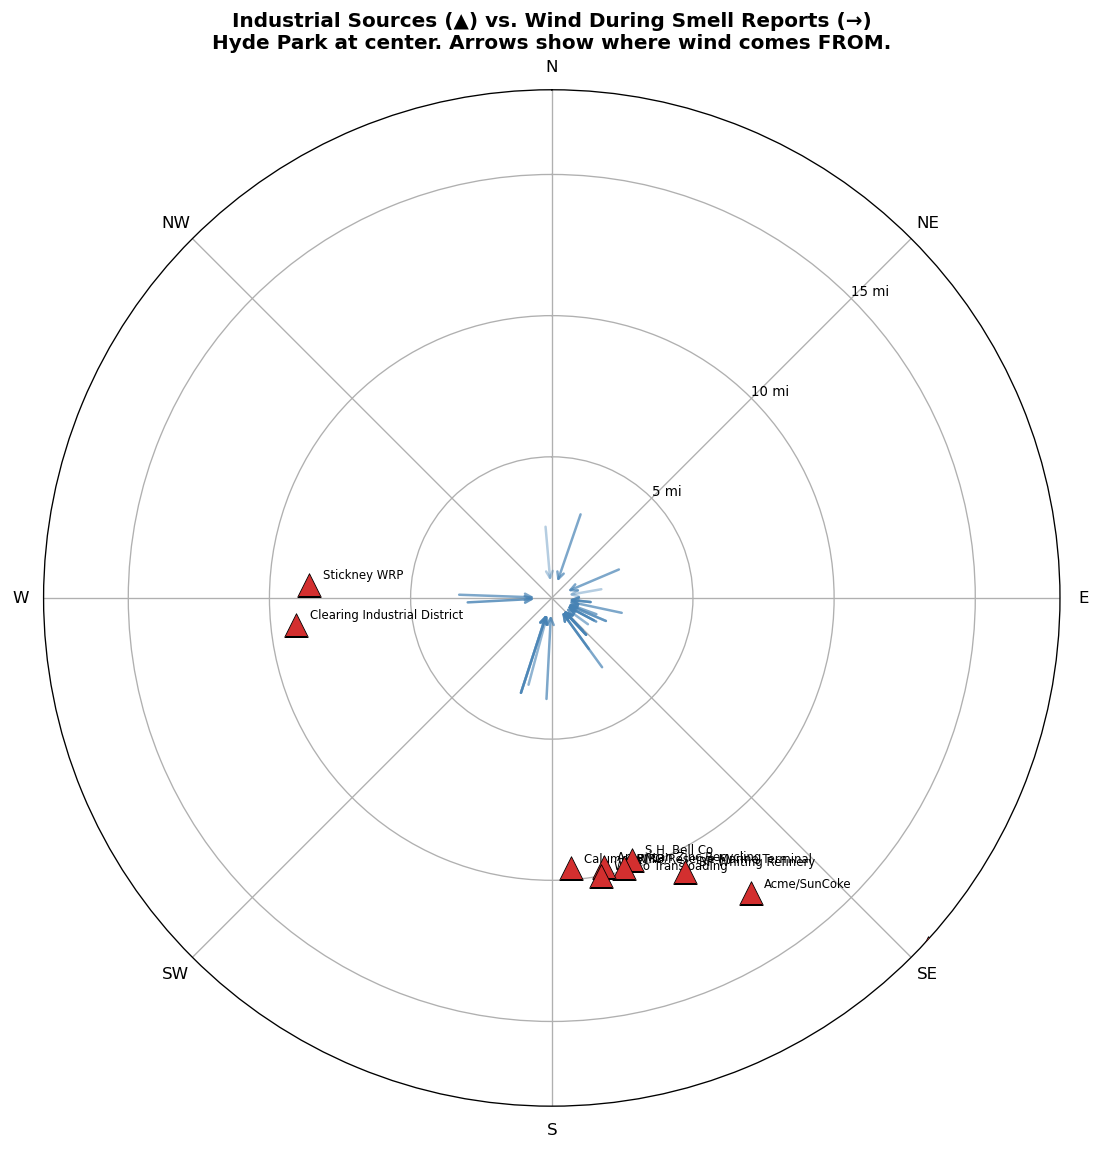

In [32]:
fig, ax = plt.subplots(figsize=(11, 11), subplot_kw={'projection': 'polar'})
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)

# Plot sources
for _, s in src_df.iterrows():
    if s['dist_mi'] > 20: continue
    theta = math.radians(s['bearing'])
    ax.scatter(theta, s['dist_mi'], s=200, c='#d32f2f', marker='^',
              zorder=5, edgecolors='black', linewidth=0.5)
    ax.annotate(s['name'].split('(')[0].strip(), (theta, s['dist_mi']),
                textcoords="offset points", xytext=(8, 4), fontsize=7, ha='left')

# Plot wind arrows during smell reports
for _, r in merged.iterrows():
    if pd.isna(r['wind_dir']): continue
    theta = math.radians(r['wind_dir'])
    length = min(r['wind_mph'] * 0.5, 8)
    alpha = r['intensity'] / 5 * 0.5 + 0.3
    ax.annotate('', xy=(theta, 0.5), xytext=(theta, length),
                arrowprops=dict(arrowstyle='->', color='steelblue', alpha=alpha, lw=1.5))

ax.set_rmax(18)
ax.set_rticks([5, 10, 15])
ax.set_rlabel_position(45)
ax.set_yticklabels(['5 mi', '10 mi', '15 mi'], fontsize=8)
ax.set_xticks(np.radians([0, 45, 90, 135, 180, 225, 270, 315]))
ax.set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])

ax.set_title('Industrial Sources (▲) vs. Wind During Smell Reports (→)\n'
             'Hyde Park at center. Arrows show where wind comes FROM.',
             fontsize=12, fontweight='bold', pad=25)
plt.savefig('fig_source_map.png', dpi=150, bbox_inches='tight')
plt.show()

### Angular Alignment Per Source

For each source, we compute how closely the observed wind matches the bearing to that source. A mismatch of 0° = perfect alignment. Below 30° = good match. The histograms show that BP Whiting and the Calumet corridor cluster have the most reports with tight alignment.

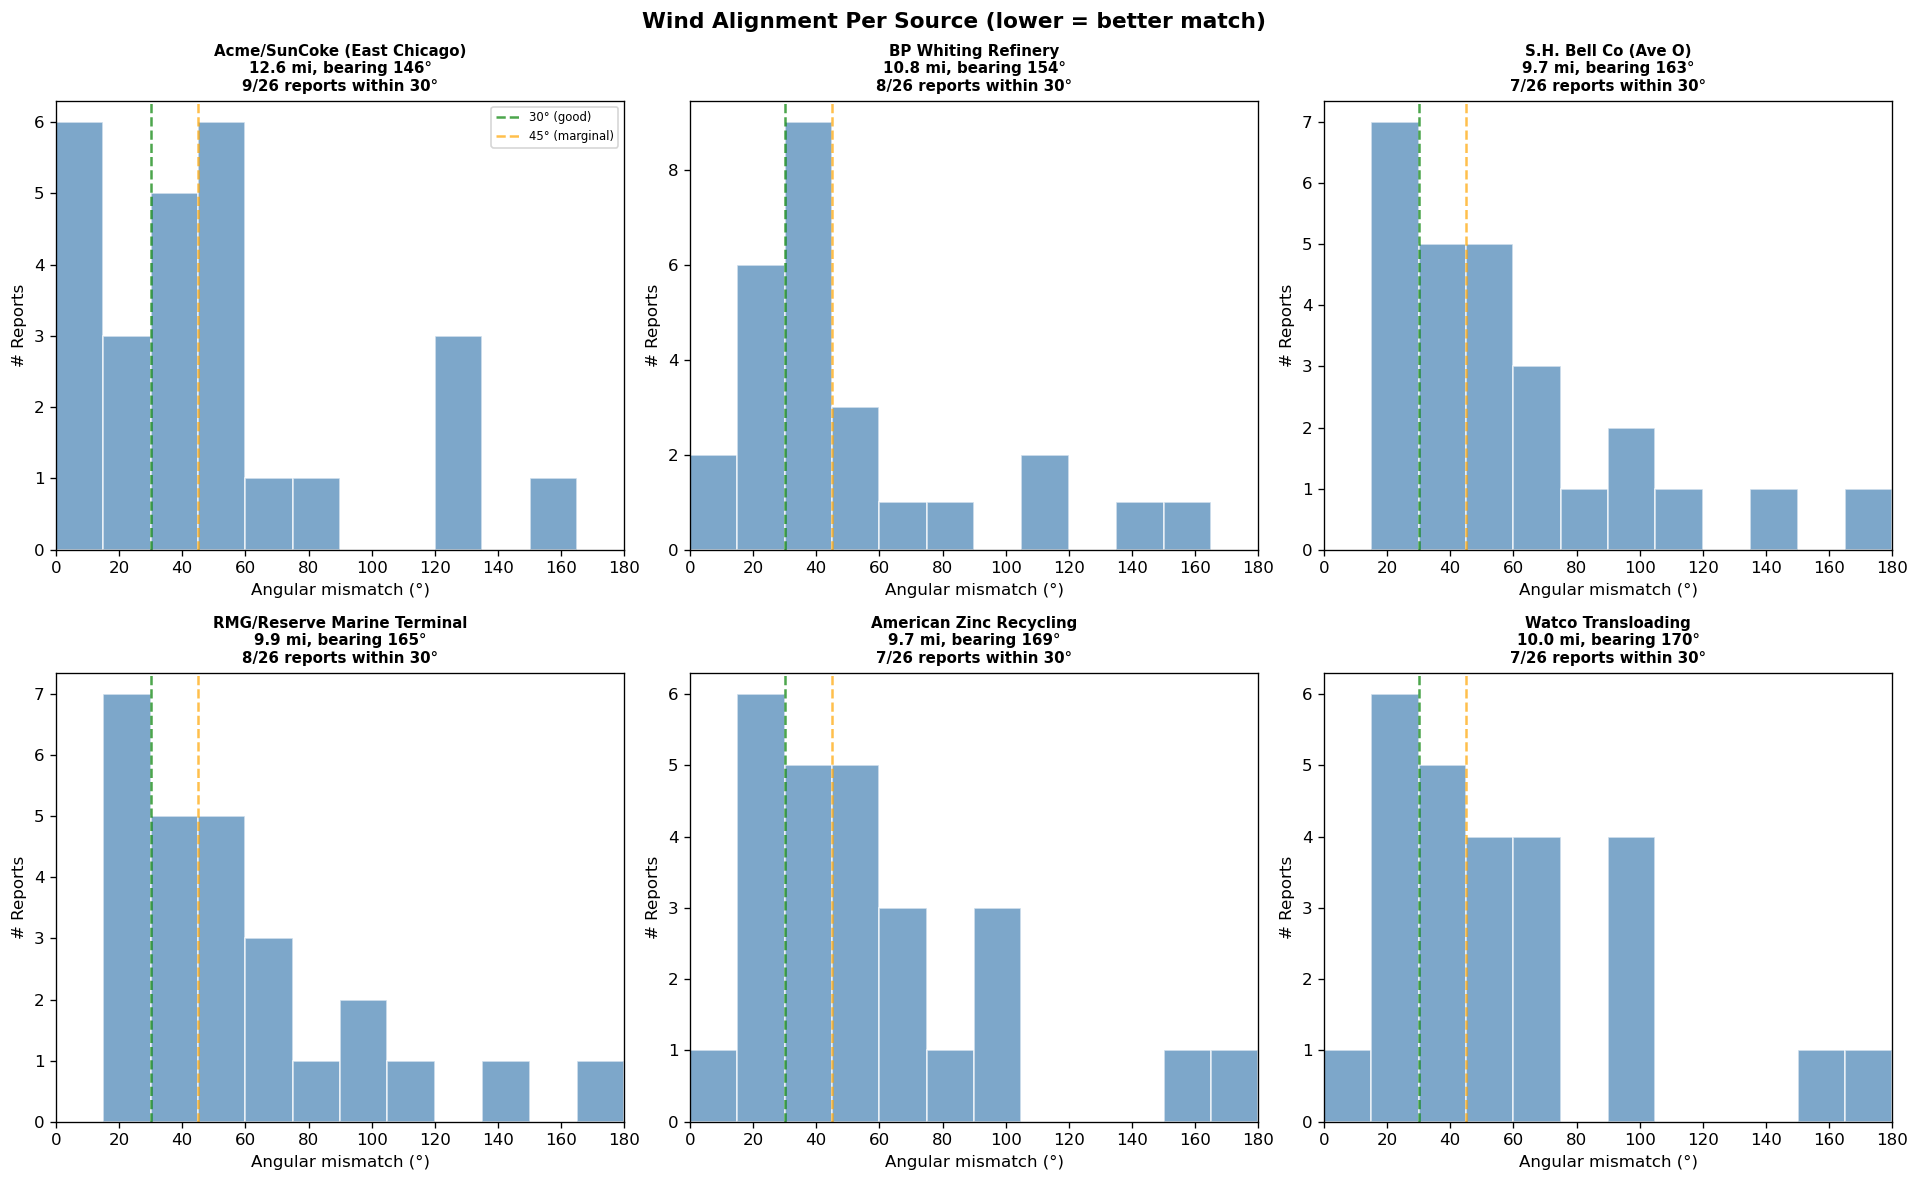

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
top_sources = [s for _, s in src_df.iterrows() if s['dist_mi'] < 15][:6]

for idx, src in enumerate(top_sources):
    ax = axes[idx // 3][idx % 3]
    diffs = [angular_diff(r['wind_dir'], src['bearing']) 
             for _, r in merged.iterrows() if not pd.isna(r['wind_dir'])]
    
    ax.hist(diffs, bins=np.arange(0, 181, 15), color='steelblue', alpha=0.7, edgecolor='white')
    ax.axvline(30, color='green', ls='--', alpha=0.7, label='30° (good)')
    ax.axvline(45, color='orange', ls='--', alpha=0.7, label='45° (marginal)')
    n_good = sum(1 for d in diffs if d <= 30)
    ax.set_xlim(0, 180)
    ax.set_title(f"{src['name']}\n{src['dist_mi']} mi, bearing {src['bearing']:.0f}°\n"
                 f"{n_good}/{len(diffs)} reports within 30°", fontsize=9, fontweight='bold')
    ax.set_xlabel('Angular mismatch (°)')
    ax.set_ylabel('# Reports')
    if idx == 0: ax.legend(fontsize=7)

plt.suptitle('Wind Alignment Per Source (lower = better match)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_source_alignment.png', dpi=150, bbox_inches='tight')
plt.show()

### Best Source Match Per Report

For each smell report, the table below shows which source has the best wind alignment, along with the estimated plume travel time (distance ÷ wind speed).

In [34]:
print(f"{'Date/Time':<16s} {'Wind':>5s} {'Spd':>5s} {'i':>2s}  {'Best Match':<30s} {'Δ°':>3s} {'Dist':>5s} {'Travel':>6s}")
print("-" * 85)

for _, r in merged.sort_values('time').iterrows():
    wd, ws = r['wind_dir'], r['wind_mph']
    if pd.isna(wd): continue
    
    best_name, best_diff, best_dist = '', 999, 0
    for _, s in src_df.iterrows():
        d = angular_diff(wd, s['bearing'])
        # Simple scoring: angular diff + penalty for distance > 20mi
        score = d + (20 if s['dist_mi'] > 20 else 0)
        if score < (angular_diff(wd, best_diff) if best_diff != 999 else 999):
            best_name = s['name']
            best_diff = s['bearing']
            best_dist = s['dist_mi']
    
    diff = angular_diff(wd, best_diff)
    travel = best_dist / max(ws, 0.5)
    match_sym = '✓' if diff <= 30 else ('~' if diff <= 45 else ' ')
    print(f"{r['time'].strftime('%m/%d %H:%M'):<16s} "
          f"{wd:5.0f}° {ws:5.1f} {r['intensity']:2.0f}  "
          f"{best_name:<30s} {diff:3.0f}° {best_dist:5.1f} {travel:5.1f}h {match_sym}")

Date/Time         Wind   Spd  i  Best Match                      Δ°  Dist Travel
-------------------------------------------------------------------------------------
10/09 21:27        144°   4.7  5  Acme/SunCoke (East Chicago)      2°  12.6   2.7h ✓
10/10 07:40        198°   7.3  3  Calumet WRP (MWRD)              22°   9.6   1.3h ✓
10/10 07:56        198°   7.3  4  Calumet WRP (MWRD)              22°   9.6   1.3h ✓
10/10 07:56        198°   7.3  3  Calumet WRP (MWRD)              22°   9.6   1.3h ✓
10/10 08:27        195°   6.6  3  Calumet WRP (MWRD)              19°   9.6   1.5h ✓
10/12 06:53        136°   3.4  3  US Steel Gary Works              3°  18.2   5.4h ✓
10/12 07:16        137°   3.8  4  US Steel Gary Works              4°  18.2   4.8h ✓
10/12 07:17        137°   3.8  4  US Steel Gary Works              4°  18.2   4.8h ✓
10/12 07:42        137°   3.8  5  US Steel Gary Works              4°  18.2   4.8h ✓
10/12 08:18        126°   3.4  3  US Steel Gary Works              7

---
## 5. Interpretation

### What the data shows

The smell reports are **not random**. They occur preferentially when wind blows from a specific arc — the ESE through SSE (roughly 110°–170°) — which is exactly the direction of the Calumet industrial corridor and NW Indiana heavy industry.

The dominant wind during the largest episodes (Oct 12, Oct 25–26) comes from 118°–137°, pointing toward:
- **Acme/SunCoke coke plant** in East Chicago, IN (bearing 146°, 13 mi)
- **US Steel Gary Works** (bearing 133°, 18 mi)
- **BP Whiting Refinery** (bearing 154°, 11 mi)

The Oct 10 and Oct 17 episodes had SSW wind (~195°), which aligns more with the **Calumet River corridor** facilities — American Zinc Recycling (169°), S.H. Bell (163°), and the Calumet Water Reclamation Plant (176°).

### Why we probably can't pin it to one facility

At 10–15 miles, atmospheric turbulence spreads a plume across 20°–40° of arc. The Calumet corridor sources sit in a 15° band (154°–176°), and the coke/steel plants in Indiana cover another 15° (133°–146°). When wind comes from this broad SE quadrant, **the plume from multiple sources mixes** before reaching Hyde Park. Different nights likely emphasize different sources depending on the exact bearing and conditions.

### The "burning plastic" descriptor

Coke oven emissions are one of the closest matches to what people describe as "burning plastic" — they produce complex mixtures of PAHs, benzene, and coal tar volatiles that have an acrid, synthetic, plasticky character. This is consistent with the SunCoke plant and Gary Works coke ovens being major contributors, with BP Whiting's petroleum VOCs adding to the mix.

### The two westerly-wind reports

The Oct 31 and Nov 3 reports occurred with due-west wind (~270°). These point toward the Clearing industrial district and Stickney wastewater plant, both ~9 miles west. This appears to be a **separate source/phenomenon** from the dominant SE pattern.

### Limitations

- **39 reports from a convenience sample** — not a random population survey. The enrichment ratio is robust (2.4×), but statistical power is limited.
- **Hourly wind resolution** — the actual wind at the moment of the smell may differ from the nearest hour's observation.
- **No air quality data** — this analysis shows *correlation* between wind direction and smell reports, not a measured pollutant level. Correlating with PurpleAir PM2.5 data would strengthen the case.
- **Self-selection bias** — people may be more likely to report when they already suspect an industrial source.

---
## Appendix: Data Dictionary

**`hyde_park_smell_reports_cleaned.csv`** — Survey responses (emails removed)
| Column | Description |
|--------|-------------|
| Timestamp | Form submission time (Central) |
| Where are you? | Cross-street or address |
| What best-describes what you smell? | Free-text description |
| How strong is the smell... | Intensity 1–5 |
| Optional: Is there anything else... | Free-text comments |
| Optional: When did you notice this smell? | "Just Now" or "At least an hour ago" |
| What day did you notice this smell? | Date (for retrospective reports) |
| About what time did you notice this smell? | Time (for retrospective reports) |

**`open_meteo_hyde_park.json`** — Hourly weather, Oct 1 – Nov 5, 2025
| Field | Description |
|-------|-------------|
| temperature_2m | Air temperature (°F) |
| relative_humidity_2m | Relative humidity (%) |
| surface_pressure | Barometric pressure (hPa) |
| wind_speed_10m | Wind speed at 10m (mph) |
| wind_direction_10m | Wind direction (°, meteorological: 0=N, 90=E, 180=S, 270=W) |